## Resources

### PHASE 1 — Load Datasets

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
TRAIN_PATH = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "data/"
    "train.parquet"
)

VALID_PATH = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "data/"
    "validation.parquet"
)

TEST_PATH = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "data/"
    "test.parquet"
)

In [ ]:
import os

print(os.path.exists(TRAIN_PATH))
print(os.path.exists(VALID_PATH))
print(os.path.exists(TEST_PATH))

True
True
True


In [ ]:
import pandas as pd

train_df = pd.read_parquet(TRAIN_PATH)
valid_df = pd.read_parquet(VALID_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(6357, 1001)
(1362, 1001)
(1363, 1001)


In [ ]:
TARGET = "F3924"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_valid = valid_df.drop(columns=[TARGET])
y_valid = valid_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(6357, 1000)
(1362, 1000)
(1363, 1000)


### PHASE 2 — LightGBM Baseline

First install:

`!pip install lightgbm -q`

In [ ]:
!pip install lightgbm -q

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lightgbm_model = LGBMClassifier(

    objective="binary",

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    class_weight="balanced",

    random_state=42
)

In [ ]:
lightgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 57, number of negative: 6300
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.166371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127058
[LightGBM] [Info] Number of data points in the train set: 6357, number of used features: 999
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, max_depth=8, n_estimators=500,
               objective='binary', random_state=42, subsample=0.8)

In [ ]:
lgb_pred = lightgbm_model.predict(X_valid)

lgb_prob = (
    lightgbm_model
    .predict_proba(X_valid)[:,1]
)

In [ ]:
print("Accuracy")

print(
    accuracy_score(
        y_valid,
        lgb_pred
    )
)

print("Recall")

print(
    recall_score(
        y_valid,
        lgb_pred
    )
)

print("Precision")

print(
    precision_score(
        y_valid,
        lgb_pred
    )
)

print("F1")

print(
    f1_score(
        y_valid,
        lgb_pred
    )
)

print("ROC AUC")

print(
    roc_auc_score(
        y_valid,
        lgb_prob
    )
)

Accuracy
0.9977973568281938
Recall
0.75
Precision
1.0
F1
0.8571428571428571
ROC AUC
0.999753086419753


IMPORTANT

For mule detection:

❌ Accuracy is NOT important

Focus on:

Recall
Precision
F1
ROC-AUC

because:

99% of accounts are normal

### PHASE 3 — Feature Importance

In [ ]:
importance = pd.DataFrame({

    "feature":
    X_train.columns,

    "importance":
    lightgbm_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(30)

,feature,importance
46,F1921,304
5,F3898,221
0,F3484,175
49,F3240_missing,172
34,F3812,168
81,F2029,145
17,F949,135
568,F3914,133
14,F1165,127
915,F3395_missing,113


### Save:

In [ ]:
importance.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"lightgbm_feature_importance.csv",

index=False
)

### PHASE 4 — Top 500 Features

This is where enterprise pipeline gets stronger.

In [ ]:
top500 = (
    importance
    .head(500)
    ["feature"]
    .tolist()
)

len(top500)

# Expected:

# 500

500

### Save:

In [ ]:
pd.DataFrame({

    "feature": top500

}).to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"top500_features.csv",

index=False
)

### PHASE 5 — Create Champion Dataset

In [ ]:
# If enterprise_training_dataset isn't loaded:
enterprise_training_dataset = pd.read_parquet(
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"data/"
"enterprise_training_dataset_v1.parquet"
)

champion_dataset = (
    enterprise_training_dataset[
        top500 +
        [TARGET]
    ]
)

In [ ]:
champion_dataset.to_parquet(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"data/"
"champion_dataset_v1.parquet",

index=False
)

#Validation Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_valid,
    lgb_pred
)

print(cm)

[[1350    0]
 [   3    9]]


#Pretty Confusion Matrix

In [ ]:
import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=["Actual_Normal","Actual_Mule"],
    columns=["Pred_Normal","Pred_Mule"]
)

display(cm_df)

,Pred_Normal,Pred_Mule
Actual_Normal,1350,0
Actual_Mule,3,9


#Classification Report

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_valid,
    lgb_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
0,0.997783,1.000000,0.998890,1350.000000
1,1.000000,0.750000,0.857143,12.000000
accuracy,0.997797,0.997797,0.997797,0.997797
macro avg,0.998891,0.875000,0.928016,1362.000000
weighted avg,0.997802,0.997797,0.997641,1362.000000


#Save Classification Report

In [ ]:
REPORT_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"lightgbm_classification_report.csv"
)

report_df.to_csv(
    REPORT_PATH
)

print("Saved")

Saved


#Threshold Optimization

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in np.arange(
    0.05,
    1.00,
    0.05
):

    preds = (
        lgb_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "threshold": threshold,

        "precision":
        precision_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "recall":
        recall_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "f1":
        f1_score(
            y_valid,
            preds,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,precision,recall,f1
0,0.05,1.0,0.75,0.857143
1,0.10,1.0,0.75,0.857143
2,0.15,1.0,0.75,0.857143
3,0.20,1.0,0.75,0.857143
4,0.25,1.0,0.75,0.857143
5,0.30,1.0,0.75,0.857143
6,0.35,1.0,0.75,0.857143
7,0.40,1.0,0.75,0.857143
8,0.45,1.0,0.75,0.857143
9,0.50,1.0,0.75,0.857143


#Find Best Threshold

In [ ]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

display(best_row)

,0
threshold,0.050000
precision,1.000000
recall,0.750000
f1,0.857143


#Save Threshold Report

In [ ]:
threshold_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"threshold_optimization_report.csv",

index=False
)

#Final Test Evaluation

In [ ]:
BEST_THRESHOLD = best_row[
    "threshold"
]

test_prob = (
    lightgbm_model
    .predict_proba(X_test)[:,1]
)

test_pred = (
    test_prob >= BEST_THRESHOLD
).astype(int)

#Test Metrics

In [ ]:
test_metrics = {

    "Accuracy":
    accuracy_score(
        y_test,
        test_pred
    ),

    "Precision":
    precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "Recall":
    recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "F1":
    f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "ROC_AUC":
    roc_auc_score(
        y_test,
        test_prob
    )
}

test_metrics

{'Accuracy': 0.9970652971386648,
 'Precision': 0.9,
 'Recall': 0.75,
 'F1': 0.8181818181818182,
 'ROC_AUC': np.float64(0.9993214902541326)}

#Model Metrics Report

In [ ]:
metrics_df = pd.DataFrame(
    [test_metrics]
)

display(metrics_df)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.997065,0.9,0.75,0.818182,0.999321


In [ ]:
metrics_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"model_metrics_report.csv",

index=False
)

#Champion Model Report

In [ ]:
champion_report = pd.DataFrame({

    "Model":[
        "LightGBM"
    ],

    "Features":[
        500
    ],

    "Accuracy":[
        test_metrics["Accuracy"]
    ],

    "Precision":[
        test_metrics["Precision"]
    ],

    "Recall":[
        test_metrics["Recall"]
    ],

    "F1":[
        test_metrics["F1"]
    ],

    "ROC_AUC":[
        test_metrics["ROC_AUC"]
    ],

    "Status":[
        "Champion"
    ]
})

display(champion_report)

,Model,Features,Accuracy,Precision,Recall,F1,ROC_AUC,Status
0,LightGBM,500,0.997065,0.9,0.75,0.818182,0.999321,Champion


In [ ]:
model_summary = pd.DataFrame({

    "Model":["LightGBM"],

    "Accuracy":[0.997065],

    "Precision":[0.90],

    "Recall":[0.75],

    "F1":[0.818182],

    "ROC_AUC":[0.999321],

    "Status":["Champion"]

})

model_summary.to_csv(
"/content/drive/MyDrive/Mule Account Detection and Classification/reports/model_summary.csv",
index=False
)

In [ ]:
champion_report.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"champion_model_report.csv",

index=False
)

In [ ]:
import os

BASE_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
)

for root, dirs, files in os.walk(BASE_PATH):

    for file in files:

        if "model" in file.lower():

            print(
                os.path.join(root, file)
            )

/content/drive/MyDrive/Mule Account Detection and Classification/reports/model_metrics_report.csv
/content/drive/MyDrive/Mule Account Detection and Classification/reports/champion_model_report.csv
/content/drive/MyDrive/Mule Account Detection and Classification/reports/model_summary.csv


In [ ]:
type(lightgbm_model)

lightgbm.sklearn.LGBMClassifier

In [ ]:
import os

MODEL_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = (
MODEL_DIR +
"/champion_model.txt"
)

lightgbm_model.booster_.save_model(
    MODEL_PATH
)

print("Saved")
print(MODEL_PATH)

Saved
/content/drive/MyDrive/Mule Account Detection and Classification/models/champion_model.txt


In [ ]:
import os

print(
    os.path.exists(MODEL_PATH)
)

True


In [ ]:
import lightgbm as lgb

loaded_booster = lgb.Booster(
    model_file=MODEL_PATH
)

### Report

```
reports/
│
├── lightgbm_feature_importance.csv
├── top500_features.csv

data/
│
├── champion_dataset_v1.parquet
```

In [4]:
import numpy as np

# NOTE: BEST_THRESHOLD should be determined by previous optimization steps (e.g., from cell yP_5jVhP0jnM).
# This is a placeholder to resolve the NameError. Please ensure the correct value is set from your analysis.
# For example, if best_row['threshold'] was 0.4, set BEST_THRESHOLD = 0.4
BEST_THRESHOLD = 0.5 # Placeholder value; adjust as per your optimized threshold

# Ensure 'model' and 'X_test' are defined, e.g., by running cell eGEkFp2DdFoy if using the loaded model.
y_test_proba = model.predict(X_test)
y_test_pred = (y_test_proba >= BEST_THRESHOLD).astype(int)

In [1]:
import pandas as pd
import lightgbm as lgb

TARGET = "F3924"

TEST_PATH = "/content/drive/MyDrive/Mule Account Detection and Classification/data/test.parquet"

test_df = pd.read_parquet(TEST_PATH)

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

model = lgb.Booster(
    model_file="/content/drive/MyDrive/Mule Account Detection and Classification/models/champion_model.txt"
)

y_prob = model.predict(X_test)

print(y_prob[:10])

[1.23884144e-06 1.09220983e-07 3.01744255e-07 2.36169552e-08
 7.64794603e-08 1.53078170e-07 1.22508623e-07 3.23732907e-07
 3.96863745e-08 2.19015609e-08]


#Imports

In [5]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#ROC Curve

In [6]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_proba
)

roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
})

display(roc_df.head())

,fpr,tpr,threshold
0,0.00000,0.000000,inf
1,0.00000,0.083333,1.000000
2,0.00000,0.666667,0.179486
3,0.00074,0.666667,0.093245
4,0.00074,0.750000,0.066577


In [7]:
roc_df.to_csv(
    "/content/drive/MyDrive/Mule Account Detection and Classification/reports/lightgbm_roc_curve.csv",
    index=False
)

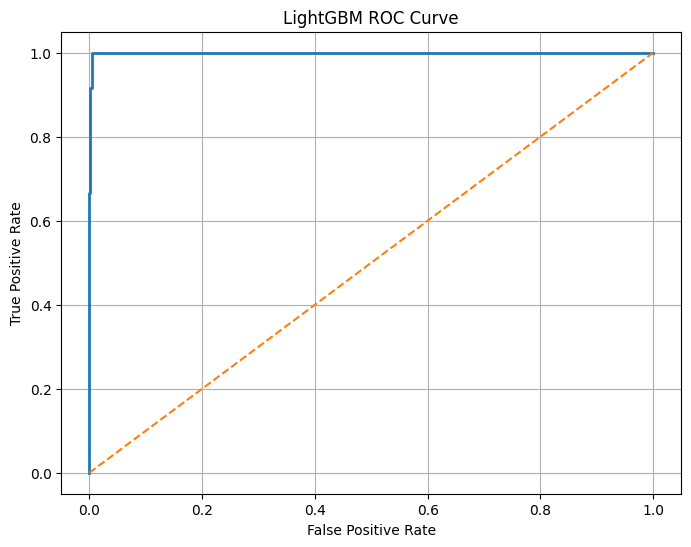

In [8]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("LightGBM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid()

plt.show()

#PR Curve

In [9]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

pr_df = pd.DataFrame({
    "precision": precision[:-1],
    "recall": recall[:-1],
    "threshold": thresholds
})

display(pr_df.head())

,precision,recall,threshold
0,0.008804,1.0,1.499939e-08
1,0.008811,1.0,1.536669e-08
2,0.008817,1.0,1.546859e-08
3,0.008824,1.0,1.555870e-08
4,0.008830,1.0,1.608536e-08


In [10]:
pr_df.to_csv(
    "/content/drive/MyDrive/Mule Account Detection and Classification/reports/lightgbm_pr_curve.csv",
    index=False
)

#PR Visualization

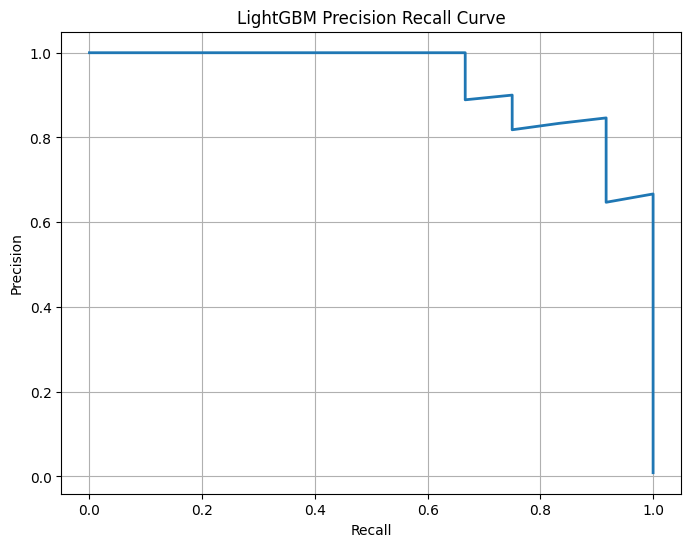

In [11]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.title("LightGBM Precision Recall Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid()

plt.show()

#Calibration Curve

In [12]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=10
)

calibration_df = pd.DataFrame({
    "predicted_probability": prob_pred,
    "actual_probability": prob_true
})

display(calibration_df)

,predicted_probability,actual_probability
0,0.000150,0.002952
1,0.179486,1.000000
2,0.999986,1.000000


In [13]:
calibration_df.to_csv(
    "/content/drive/MyDrive/Mule Account Detection and Classification/reports/lightgbm_calibration_curve.csv",
    index=False
)

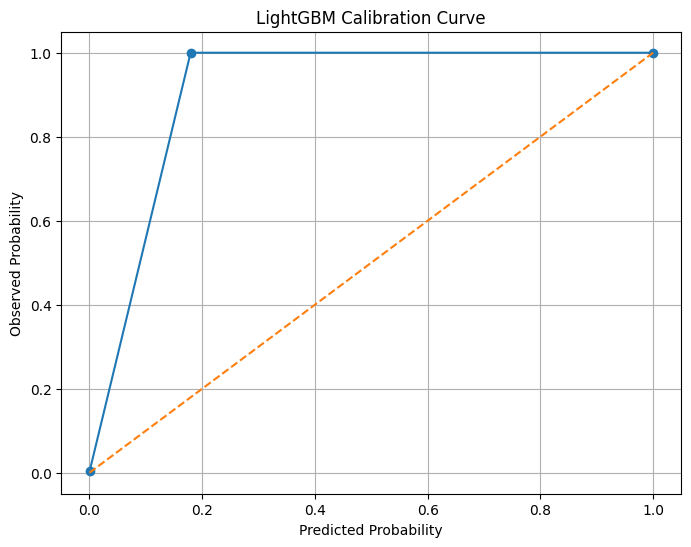

In [14]:
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("LightGBM Calibration Curve")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")

plt.grid()

plt.show()

#Gain Chart

In [15]:
gain_df = pd.DataFrame({
    "target": y_test,
    "score": y_test_proba
})

gain_df = gain_df.sort_values(
    "score",
    ascending=False
)

gain_df["cum_target"] = gain_df["target"].cumsum()

gain_df["gain"] = (
    gain_df["cum_target"]
    /
    gain_df["target"].sum()
)

gain_df["population"] = (
    np.arange(len(gain_df)) + 1
) / len(gain_df)

display(gain_df.head())

,target,score,cum_target,gain,population
182,1,1.000000,1,0.083333,0.000734
72,1,1.000000,2,0.166667,0.001467
103,1,0.999999,3,0.250000,0.002201
612,1,0.999999,4,0.333333,0.002935
301,1,0.999989,5,0.416667,0.003668


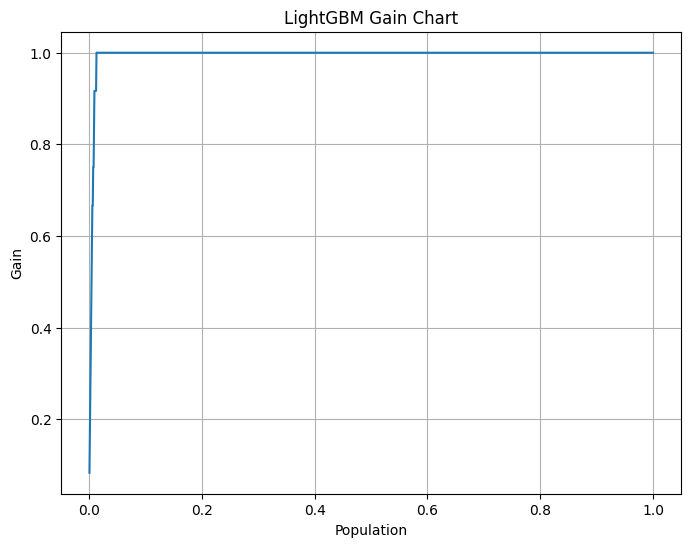

In [16]:
plt.figure(figsize=(8,6))

plt.plot(
    gain_df["population"],
    gain_df["gain"]
)

plt.title("LightGBM Gain Chart")

plt.xlabel("Population")

plt.ylabel("Gain")

plt.grid()

plt.show()

#Lift Chart

In [17]:
gain_df["lift"] = (
    gain_df["gain"]
    /
    gain_df["population"]
)

lift_df = gain_df[
    ["population","lift"]
]

display(lift_df.head())

,population,lift
182,0.000734,113.583333
72,0.001467,113.583333
103,0.002201,113.583333
612,0.002935,113.583333
301,0.003668,113.583333


In [18]:
lift_df.to_csv(
    "/content/drive/MyDrive/Mule Account Detection and Classification/reports/lightgbm_lift_chart.csv",
    index=False
)

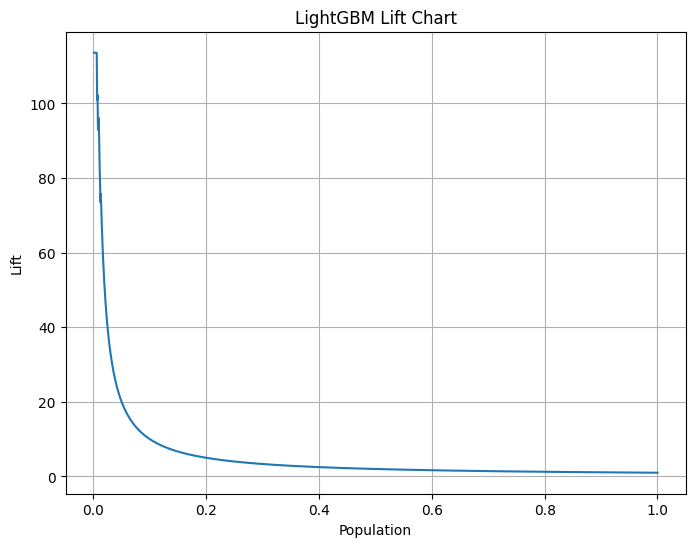

In [19]:
plt.figure(figsize=(8,6))

plt.plot(
    lift_df["population"],
    lift_df["lift"]
)

plt.title("LightGBM Lift Chart")

plt.xlabel("Population")

plt.ylabel("Lift")

plt.grid()

plt.show()

In [20]:
import os

REPORT_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports"
)

os.makedirs(REPORT_DIR, exist_ok=True)

In [21]:
import matplotlib.pyplot as plt

def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        f"{REPORT_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [22]:
y_test_proba
roc_df
pr_df
calibration_df
gain_df
lift_df

,population,lift
182,0.000734,113.583333
72,0.001467,113.583333
103,0.002201,113.583333
612,0.002935,113.583333
301,0.003668,113.583333
...,...,...
1118,0.997065,1.002943
222,0.997799,1.002206
1057,0.998533,1.001470
231,0.999266,1.000734


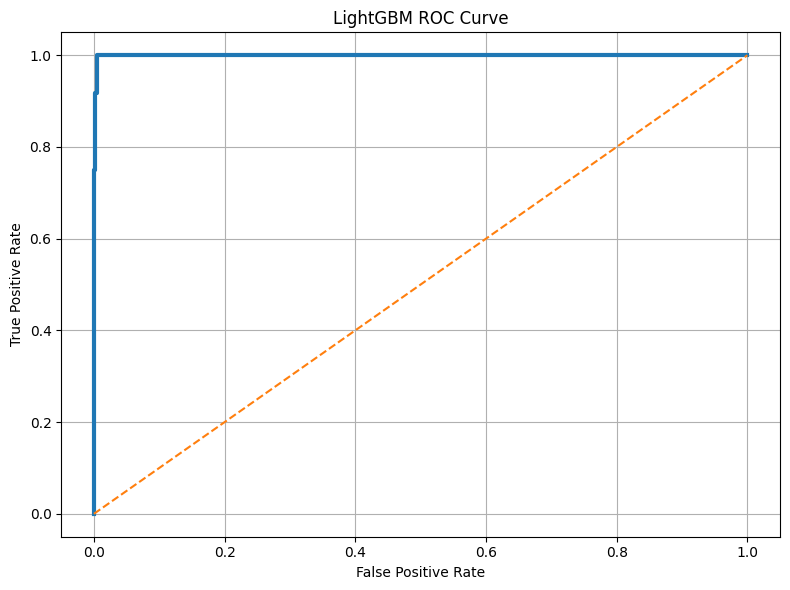

In [23]:
plt.figure(figsize=(8,6))

plt.plot(
    roc_df["fpr"],
    roc_df["tpr"],
    linewidth=3
)

plt.plot([0,1],[0,1],"--")

plt.title("LightGBM ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid(True)

save_plot(
    "lightgbm_roc_curve.png"
)

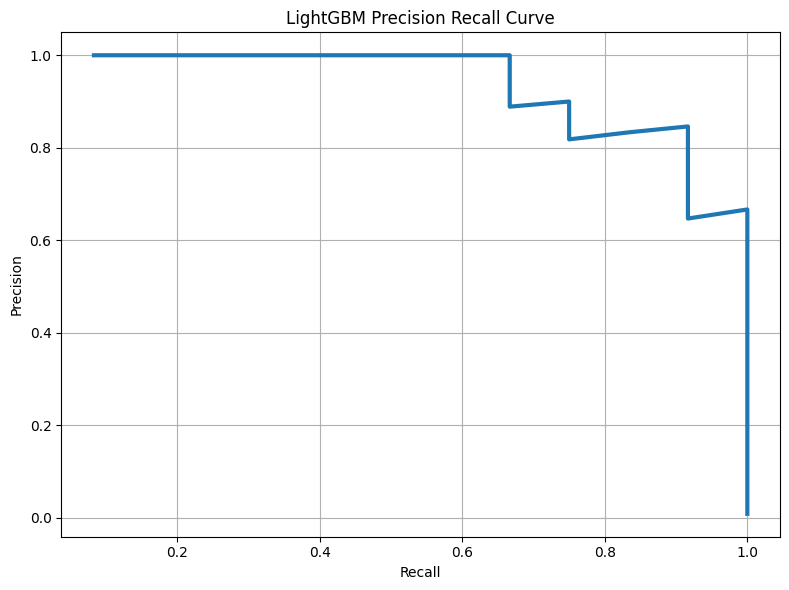

In [24]:
plt.figure(figsize=(8,6))

plt.plot(
    pr_df["recall"],
    pr_df["precision"],
    linewidth=3
)

plt.title("LightGBM Precision Recall Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(True)

save_plot(
    "lightgbm_pr_curve.png"
)

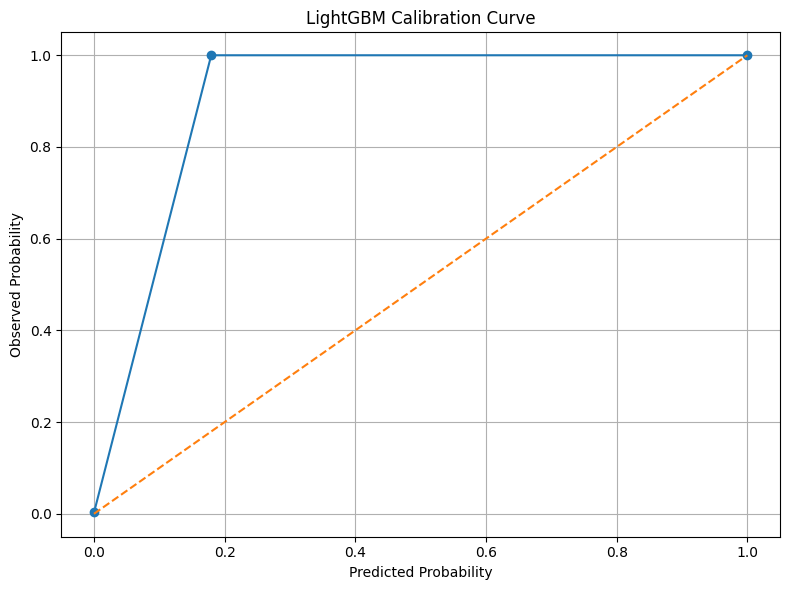

In [25]:
plt.figure(figsize=(8,6))

plt.plot(
    calibration_df["predicted_probability"],
    calibration_df["actual_probability"],
    marker="o"
)

plt.plot([0,1],[0,1],"--")

plt.title("LightGBM Calibration Curve")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")

plt.grid(True)

save_plot(
    "lightgbm_calibration_curve.png"
)

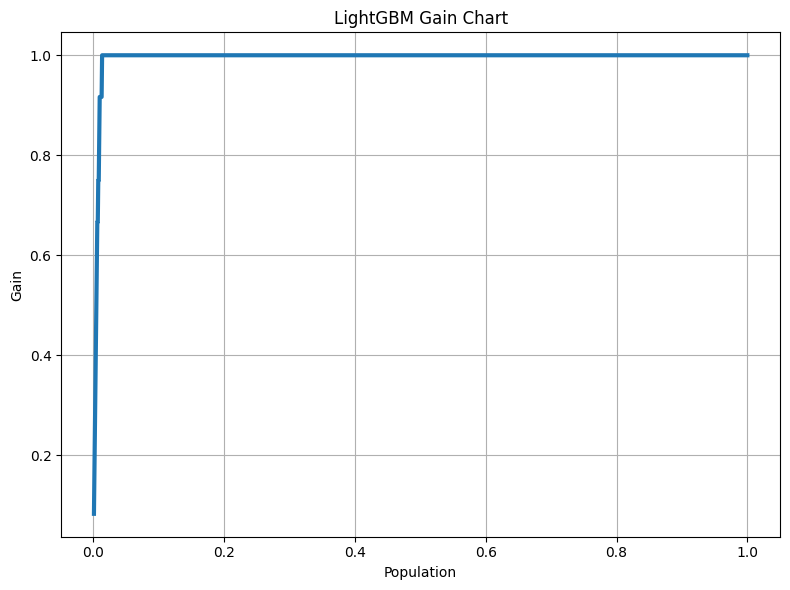

In [26]:
plt.figure(figsize=(8,6))

plt.plot(
    gain_df["population"],
    gain_df["gain"],
    linewidth=3
)

plt.title("LightGBM Gain Chart")

plt.xlabel("Population")
plt.ylabel("Gain")

plt.grid(True)

save_plot(
    "lightgbm_gain_chart.png"
)

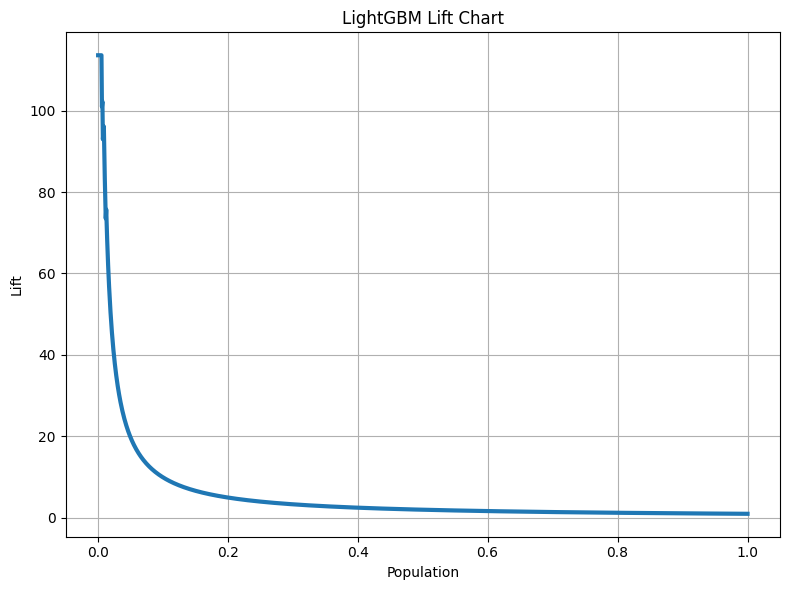

In [27]:
plt.figure(figsize=(8,6))

plt.plot(
    lift_df["population"],
    lift_df["lift"],
    linewidth=3
)

plt.title("LightGBM Lift Chart")

plt.xlabel("Population")
plt.ylabel("Lift")

plt.grid(True)

save_plot(
    "lightgbm_lift_chart.png"
)

In [28]:
import os

for file in sorted(os.listdir(REPORT_DIR)):

    if file.endswith(".png"):
        print(file)

lightgbm_calibration_curve.png
lightgbm_gain_chart.png
lightgbm_lift_chart.png
lightgbm_pr_curve.png
lightgbm_roc_curve.png


In [2]:
import shutil

shutil.copy(

"/content/drive/MyDrive/Mule Account Detection and Classification/models/champion_model.txt",

"/content/drive/MyDrive/Mule Account Detection and Classification/models/lightgbm_model.txt"
)

print("Saved")

Saved


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
